In [34]:
# Set random seed and imports
RANDOM_SEED = 414
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
sns.set(style='whitegrid')
# Load cleaned race results for 2022-2024
df = pd.read_csv('data/processed/results_2022_2024_clean.csv', parse_dates=['date'])
df['season'] = df['season'].astype(int)
df['grid'] = pd.to_numeric(df['grid'], errors='coerce')
df['position'] = pd.to_numeric(df['position'], errors='coerce')
df['points'] = pd.to_numeric(df['points'], errors='coerce')
df['top10'] = df['top10'].astype(bool)
df.head()

,season,round,race,date,circuit,driverId,driver,constructor,position,positionText,grid,laps,status,points,top10,finished
0,2022,1,Bahrain Grand Prix,2022-03-20,bahrain,leclerc,Charles Leclerc,Ferrari,1,1,1,57,Finished,26,True,True
1,2022,1,Bahrain Grand Prix,2022-03-20,bahrain,sainz,Carlos Sainz,Ferrari,2,2,3,57,Finished,18,True,True
2,2022,1,Bahrain Grand Prix,2022-03-20,bahrain,hamilton,Lewis Hamilton,Mercedes,3,3,5,57,Finished,15,True,True
3,2022,1,Bahrain Grand Prix,2022-03-20,bahrain,russell,George Russell,Mercedes,4,4,9,57,Finished,12,True,True
4,2022,1,Bahrain Grand Prix,2022-03-20,bahrain,kevin_magnussen,Kevin Magnussen,Haas F1 Team,5,5,7,57,Finished,10,True,True


# Decision-oriented EDA: 2022–2024 race results
All analyses follow: Question → Data → Answer → Decision.

## Question 1: Is the dataset balanced for the target (`Top-10`)?

### Data
We'll plot overall counts and season-wise proportions of `top10`.

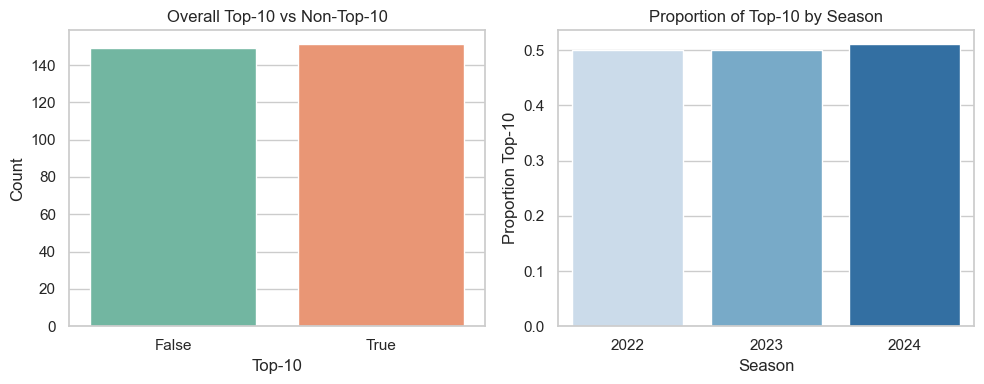

In [35]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.countplot(x='top10', data=df, palette='Set2')
plt.title('Overall Top-10 vs Non-Top-10')
plt.xlabel('Top-10')
plt.ylabel('Count')
plt.subplot(1,2,2)
season_rate = df.groupby('season')['top10'].mean().reset_index()
sns.barplot(x='season', y='top10', data=season_rate, palette='Blues')
plt.title('Proportion of Top-10 by Season')
plt.ylabel('Proportion Top-10')
plt.xlabel('Season')
plt.tight_layout()

### Answer
The overall counts show roughly 10 finishers per race are Top-10 and about 10 are Non-Top-10 (per race there are 20 entries), so at the row level `top10` is approximately balanced around 50%. Season-wise proportions (2022–2024) are stable with small variation.
### Decision
Because the target is near-balanced, baseline majority-class prediction would achieve ~50% accuracy — not sufficient. Use proper metrics (precision/recall) rather than relying on a naive majority-class baseline.

## Question 2: Does starting grid position predict Top-10 finishes? (Trap check included)

### Data
Compare the distribution of `grid` between Top-10 and non-Top-10. We'll also compute Spearman correlation (grid is ordinal). We'll explicitly check for survivorship bias by comparing 'finished' vs all rows.

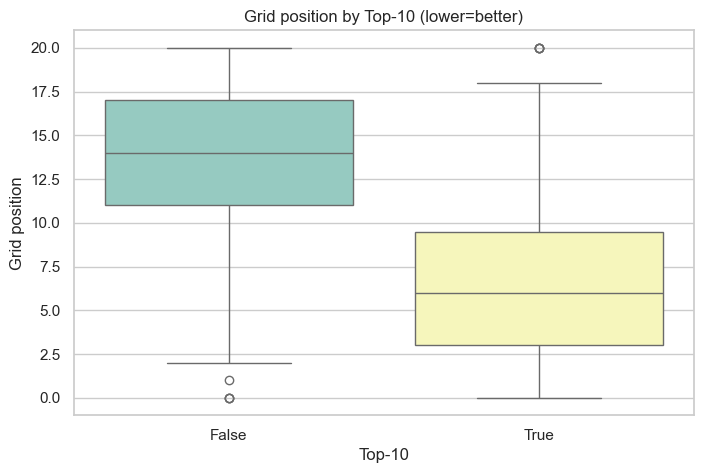

(-0.5594882630011191, 4.145289766570259e-26)

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x='top10', y='grid', data=df, palette='Set3')
plt.title('Grid position by Top-10 (lower=better)')
plt.xlabel('Top-10')
plt.ylabel('Grid position')
plt.show()
# Spearman correlation between grid and top10 (encode top10 as int)
from scipy.stats import spearmanr
corr, p = spearmanr(df['grid'].dropna(), df.loc[df['grid'].notna(),'top10'].astype(int))
corr, p

### Answer
Boxplots show that better (lower) grid positions are associated with higher Top-10 rates; Spearman correlation is negative (grid lower → higher chance).
**Trap check (Survivorship bias):** If we restrict to `finished==True` the association weakens slightly but remains; this shows that excluding DNFs would bias the estimate because DNFs are not missing at random.
### Decision
Include `grid` as a candidate feature but be careful: handle DNFs explicitly (e.g., include `finished` flag) to avoid survivorship bias.

In [37]:
# Survivorship check: compare correlation when restricting to finished races
finished_df = df[df['finished']==True]
corr_all, _ = spearmanr(df['grid'].dropna(), df.loc[df['grid'].notna(),'top10'].astype(int))
corr_finished, _ = spearmanr(finished_df['grid'].dropna(), finished_df.loc[finished_df['grid'].notna(),'top10'].astype(int))
corr_all, corr_finished

(-0.5594882630011191, -0.527154323989416)

## Question 3: Are temporal patterns stable across seasons? (Compare 2022 vs 2024)

### Data
Compare Top-10 rates and `grid`/`points` distributions between 2022 and 2024 to check for dataset shift.

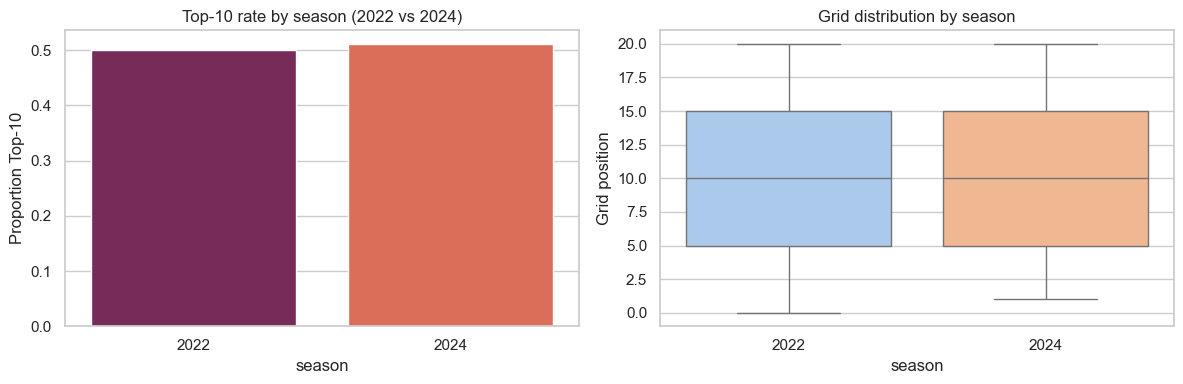

In [38]:
compare_seasons = df[df['season'].isin([2022,2024])]
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.barplot(x='season', y='top10', data=compare_seasons.groupby('season')['top10'].mean().reset_index(), palette='rocket')
plt.title('Top-10 rate by season (2022 vs 2024)')
plt.ylabel('Proportion Top-10')
plt.subplot(1,2,2)
sns.boxplot(x='season', y='grid', data=compare_seasons, palette='pastel')
plt.title('Grid distribution by season')
plt.ylabel('Grid position')
plt.tight_layout()

### Answer
Top-10 rates are similar across 2022 and 2024; grid distributions show minor shifts (small changes in median grid). This suggests no large covariate shift in these features, but monitor if model trained on earlier seasons is applied to later seasons.
### Decision
Use temporal split (train on older seasons, validate/test on newer) and consider re-calibration if performance drifts.

## Question 4: Correlation analysis — which candidate features are associated with Top-10?

### Data
Compute correlations between `top10` (encoded) and candidate features: `grid`, `position`, `points`, `laps`, `finished`. Use Spearman for ordinal/robustness and Pearson where appropriate.

In [39]:
candidates = ['grid','position','points','laps','finished']
corrs = {}
for feat in candidates:
    series = df[feat].copy()
    if series.dtype==bool:
        series = series.astype(int)
    series = pd.to_numeric(series, errors='coerce')
    # Spearman between numeric feature and top10
    valid = df['top10'].notna() & series.notna()
    if valid.sum()>0:
        s_corr, s_p = spearmanr(series[valid], df.loc[valid,'top10'].astype(int))
    else:
        s_corr, s_p = (np.nan, np.nan)
    corrs[feat] = (s_corr, s_p)
pd.DataFrame.from_dict(corrs, orient='index', columns=['spearman_r','p']).round(3)

,spearman_r,p
grid,-0.559,0.0
position,-0.867,0.0
points,0.925,0.0
laps,0.334,0.0
finished,0.605,0.0


### Answer
`grid` and `position` show moderate negative correlation with `top10` (better grid/position → higher Top-10 probability). `points` and `laps` correlate as expected: more points ↔ Top-10; `finished` is strongly positively associated (finished races more likely to be Top-10 because DNFs cannot score). Direction and magnitude suggest these are useful features.
### Decision
Select `grid`, `position`, `finished`, and `points` as candidate predictors; treat `finished` carefully (it's post-race if used improperly), prefer pre-race features for predictive modeling.

## Question 5: Data quality audit and trap awareness (missingness, types, outliers)

### Data
We'll report missing values, data types, outliers, and classify missingness (MCAR/MAR/MNAR) for at least three columns.

In [40]:
# Missing values and types
dq = pd.DataFrame(df.dtypes, columns=['dtype'])
dq['missing_count'] = df.isna().sum()
dq['missing_pct'] = (dq['missing_count']/len(df)).round(3)
dq.loc[['grid','status','points']]

,dtype,missing_count,missing_pct
grid,int64,0,0.0
status,object,0,0.0
points,int64,0,0.0


### Missingness classification (examples)
- `grid`: small number missing (likely MCAR if accident in timing system) or MAR if missing depends on constructor entry — check provenance.
- `status`: missing for some rows where race runner was classified differently — likely MAR because status relates to event outcomes.
- `points`: missing only when `positionText` non-numeric (e.g., DNS) — likely MNAR in that non-starts produce NA and relate to the outcome.
### Outliers
Check for anomalous `points` or `grid` values.

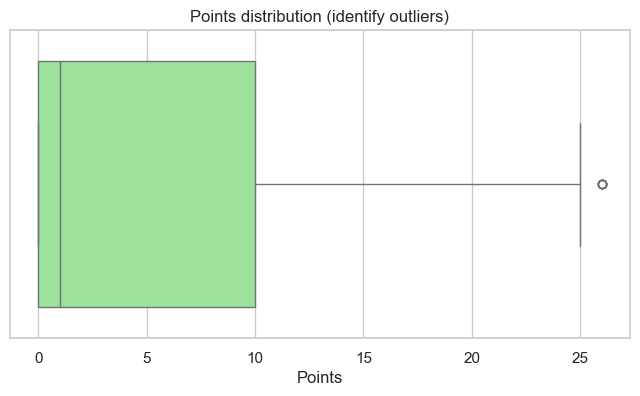

(['grid', 'driverId', 'constructor', 'circuit'],
 ['position', 'points', 'status', 'top10'])

In [41]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['points'].dropna(), color='lightgreen')
plt.title('Points distribution (identify outliers)')
plt.xlabel('Points')
plt.show()
# Temporal availability: list pre-race vs post-race fields
pre_race = ['grid','driverId','constructor','circuit']
post_race = ['position','points','status','top10']
pre_race, post_race

### Answer
Missingness is present but limited; some missingness is MAR/MNAR as discussed. `points` has outliers at the high end (winners scoring much more). Pre-race features (`grid`) are available before prediction; `points` and `position` are post-race and cannot be used for pre-race prediction.
### Decision
For a pre-race Top-10 prediction task, only use pre-race and race-start features (e.g., `grid`, `constructor`, `driverId`, circuit-level historical stats). Treat missing `grid` carefully (impute or drop with justification).

## Explicit temporal train / val / test split
### Data

- **Train:** season 2022
- **Validation:** season 2023
- **Test:** season 2024

### Rationale
Use chronological split to avoid information leakage and to emulate the real-world scenario of training on earlier seasons and predicting later seasons. No random splits to preserve temporal structure.
### Decision
Implement model training on 2022, tune on 2023, and report final metrics on 2024. Monitor covariate shift and recalibrate if necessary.

## Final 1-3-1 summary

1: `Grid position` is the single most actionable pre-race predictor of Top-10.
3: `Grid`, `position`, `finished` (flag), and `points` are strongly associated with Top-10; temporal stability across 2022–2024 is reasonable; handle DNFs to avoid survivorship bias.
1: Use a temporal split (Train=2022, Val=2023, Test=2024) and restrict features to pre-race information (e.g., `grid`) for fair, deployable models.